In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CONSTANTS
# ---------------------------------------------------

h = 6.62607015e-34       # Planck constant (J s)
c = 2.99792458e8         # Speed of light (m/s)

mu = 1.4560              # Refractive index of quartz
t = 0.003                # Etalon thickness (m)

# ---------------------------------------------------
# MAGNETIC FIELDS
# ---------------------------------------------------

B = np.array([
    0.636,
    0.546,
    0.528,
    0.492,
    0.436
])

# ---------------------------------------------------
# RADIUS DATA
# Order:
# 1a, 1b, 1c,
# 2a, 2b, 2c,
# 3a, 3b, 3c
# ---------------------------------------------------

radius_data = [

    # B1 = 636 mT
    [
        3949.3, 4850.19, 5590.295,
        6886.725, 7390.25, 7855.835,
        8824.5, 9215.16, 9595.54
    ],

    # B2 = 546 mT
    [
        3901.385, 4688.59, 5341.475,
        6848.49, 7266.72, 7679.95,
        8790.55, 9090.66, 9401.92
    ],

    # B3 = 528 mT
    [
        3898.218, 4664.54, 5271.53,
        6857.24, 7299.35, 7646.09,
        8815.2, 9164.59, 9418.92
    ],

    # B4 = 492 mT
    [
        3984.13, 4668.21, 5261.15,
        6899.63, 7316.27, 7653.39,
        8839.05, 9137.96, 9434.7
    ],

    # B5 = 436 mT
    [
        4036.95, 4643.07, 5146.54,
        6961.25, 7249.21, 7573.95,
        8904.36, 9134.18, 9380.62
    ]
]

delta_k_values = []
delta_values = []
Delta_values = []

# ---------------------------------------------------
# CALCULATIONS
# ---------------------------------------------------

for radii in radius_data:

    R2 = np.array(radii)**2

    # Reshape:
    # rows = orders
    # columns = a, b, c
    R2 = R2.reshape(3, 3)

    # -----------------------------------------------
    # Calculate delta
    # -----------------------------------------------

    delta_terms = []

    for order in range(3):

        delta_ab = R2[order, 1] - R2[order, 0]
        delta_bc = R2[order, 2] - R2[order, 1]

        delta_terms.append(delta_ab)
        delta_terms.append(delta_bc)

    delta = np.mean(delta_terms)

    # -----------------------------------------------
    # Calculate Delta
    # -----------------------------------------------

    Delta_terms = []

    for line in range(3):

        Delta_1 = R2[1, line] - R2[0, line]
        Delta_2 = R2[2, line] - R2[1, line]

        Delta_terms.append(Delta_1)
        Delta_terms.append(Delta_2)

    Delta = np.mean(Delta_terms)

    # -----------------------------------------------
    # Calculate Delta k
    # -----------------------------------------------

    delta_k = (1 / (2 * mu * t)) * (delta / Delta)

    delta_values.append(delta)
    Delta_values.append(Delta)
    delta_k_values.append(delta_k)


delta_k_values = np.array(delta_k_values)

# ---------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------

print("B(T)      delta        Delta        Delta k (m^-1)")
print("------------------------------------------------")

for i in range(len(B)):

    print(
        f"{B[i]:.3f}   "
        f"{delta_values[i]:.4e}   "
        f"{Delta_values[i]:.4e}   "
        f"{delta_k_values[i]:.4f}"
    )

B(T)      delta        Delta        Delta k (m^-1)
------------------------------------------------
0.636   7.3574e+06   3.0749e+07   27.3894
0.546   6.0854e+06   3.0429e+07   22.8923
0.528   5.8404e+06   3.0945e+07   21.6041
0.492   5.6101e+06   3.0883e+07   20.7939
0.436   4.6340e+06   3.1062e+07   17.0768



Slope = 41.740044056829184 ± 0.6286333695153725 m^-1 T^-1

Bohr magneton:
8.29143375939021e-24 ± 1.2487461525393834e-25 J/T

percentage error:
-10.594848399933033 %


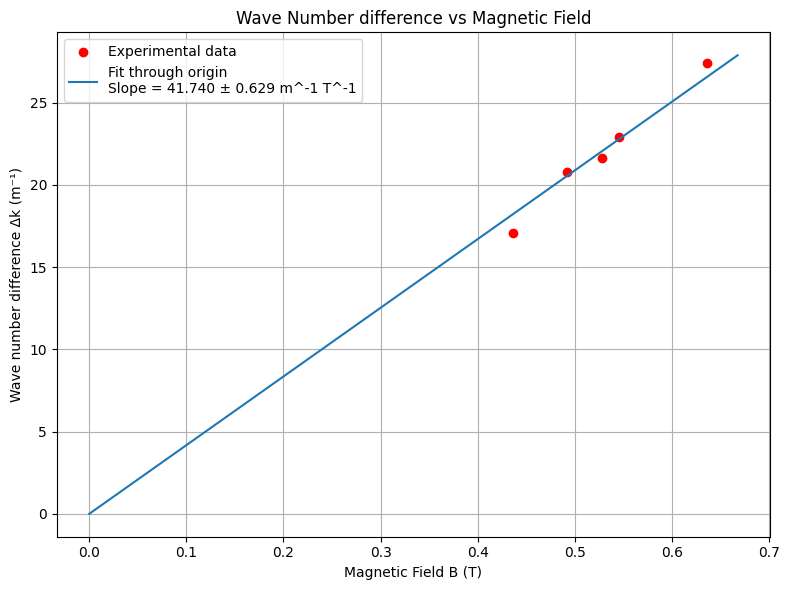

In [14]:
# ---------------------------------------------------
# FIT THROUGH ORIGIN
# ---------------------------------------------------

slope = np.sum(B * delta_k_values) / np.sum(B**2)

# Residuals (y_observed - y_fitted)
residuals = delta_k_values - slope * B

# Degrees of freedom for a zero-intercept model (N points - 1 fit parameter)
dof = len(B) - 1

# Residual variance (variance of the data around the fitted line)
residual_variance = np.sum(residuals**2) / dof

# Standard error of the slope
slope_error = np.sqrt(residual_variance / np.sum(B**2))

# Bohr magneton using adjacent splitting convention
mu_B = h * c * slope
mu_B_err= h*c*slope_error

mu_lit=9.274*1e-24
percent_err=(mu_B-mu_lit)/mu_lit*100

print("\nSlope =", slope,"\u00B1", slope_error, "m^-1 T^-1")

print("\nBohr magneton:")
print(mu_B,"\u00B1", mu_B_err, "J/T")

print("\npercentage error:")
print(percent_err, "%")
# ---------------------------------------------------
# GRAPH
# ---------------------------------------------------

B_fit = np.linspace(0, max(B) * 1.05, 100)

plt.figure(figsize=(8, 6))

plt.scatter(
    B,
    delta_k_values,
    label="Experimental data",
    color="r"
)

plt.plot(
    B_fit,
    slope * B_fit,
    label=f"Fit through origin\nSlope = {slope:.3f} \u00B1 {slope_error:.3f} m^-1 T^-1"
)

plt.xlabel("Magnetic Field B (T)")
plt.ylabel("Wave number difference Δk (m⁻¹)")

plt.title("Wave Number difference vs Magnetic Field")

plt.grid(True)
plt.legend()
plt.savefig('/home/infobreez/Muz/5th sem/modern phy lab/zeeman_plot.png')
plt.tight_layout()
plt.show()
